![ccp4.png](attachment:5a6e3f1d-98d6-4dd8-aa41-60938239b568.png)

# **Import Libraries:**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import metrics
from sklearn.metrics import roc_curve
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report

# **Load the Dataset**

In [4]:
df =pd.read_csv("/content/Churn_Modelling (1).csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# **Data Analysis:**

In [5]:
df.shape

(10000, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
df.dtypes

,0
RowNumber,int64
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64


In [9]:
df.count()

,0
RowNumber,10000
CustomerId,10000
Surname,10000
CreditScore,10000
Geography,10000
Gender,10000
Age,10000
Tenure,10000
Balance,10000
NumOfProducts,10000


# **Data Preprocessing and Cleaning:**

**Remove Duplicate Values**

In [10]:
duplicate=df[df.duplicated()]
print(duplicate)

Empty DataFrame
Columns: [RowNumber, CustomerId, Surname, CreditScore, Geography, Gender, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary, Exited]
Index: []


In [11]:
df = df.drop_duplicates()
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


**Handling Missing Values**

In [12]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


**Drop Unnecessary Columns**

In [13]:
#Drop name and ticket Columns
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

In [14]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [15]:
df.shape

(10000, 11)

**Outlier Detection**

<Axes: xlabel='Age'>

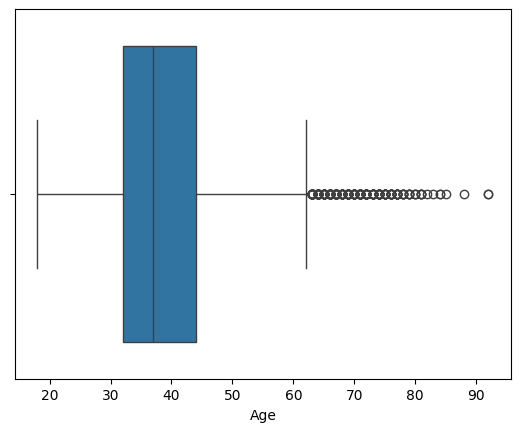

In [16]:
sns.boxplot(x=df['Age'])

In [17]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers
df = df[(df['Age'] >= lower_bound) & (df['Age'] <= upper_bound)]

In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['Age'] = scaler.fit_transform(df[['Age']])

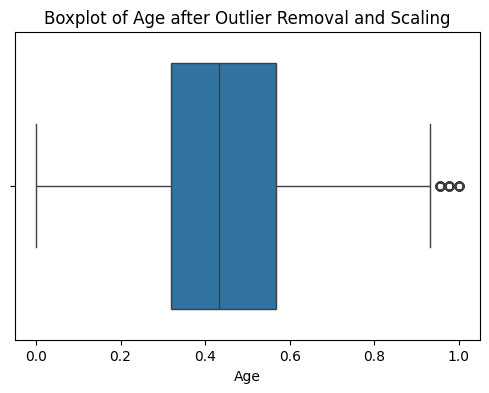

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Age'])
plt.title("Boxplot of Age after Outlier Removal and Scaling")
plt.show()

<Axes: xlabel='CreditScore'>

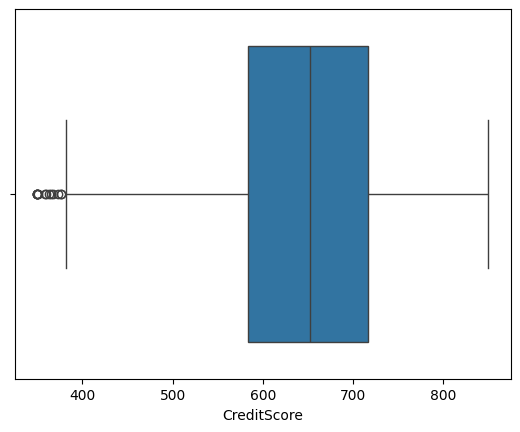

In [20]:
sns.boxplot(x=df['CreditScore'])

In [21]:
Q1 = df['CreditScore'].quantile(0.25)
Q3 = df['CreditScore'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers
df = df[(df['CreditScore'] >= lower_bound) & (df['CreditScore'] <= upper_bound)]

In [22]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['CreditScore'] = scaler.fit_transform(df[['CreditScore']])

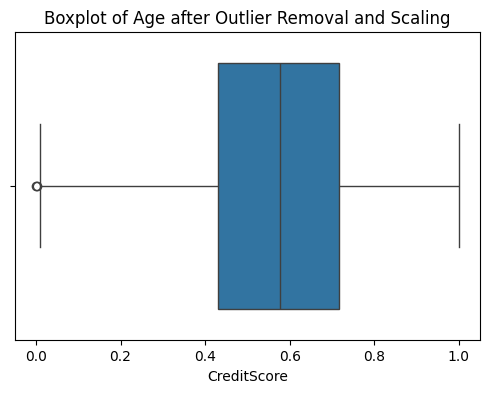

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.boxplot(x=df['CreditScore'])
plt.title("Boxplot of Age after Outlier Removal and Scaling")
plt.show()

<Axes: xlabel='Tenure'>

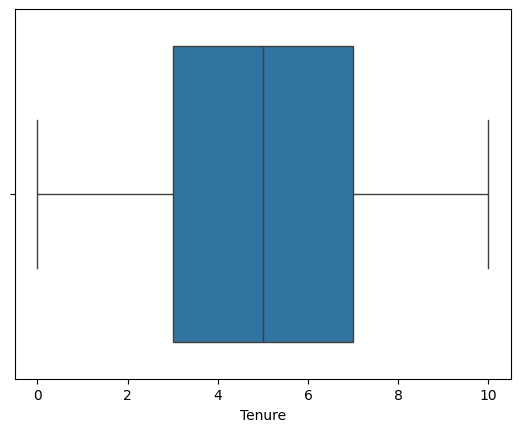

In [24]:
sns.boxplot(x=df['Tenure'])

<Axes: xlabel='Balance'>

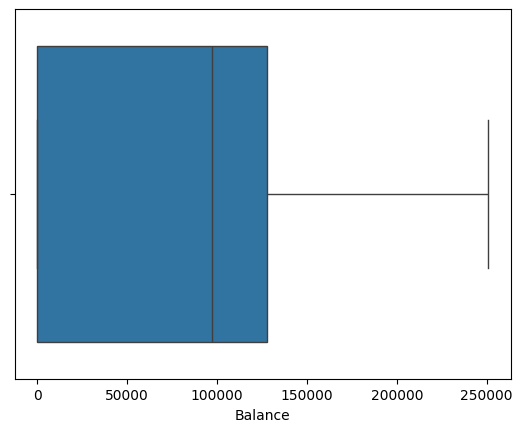

In [25]:
sns.boxplot(x=df['Balance'])


<Axes: xlabel='NumOfProducts'>

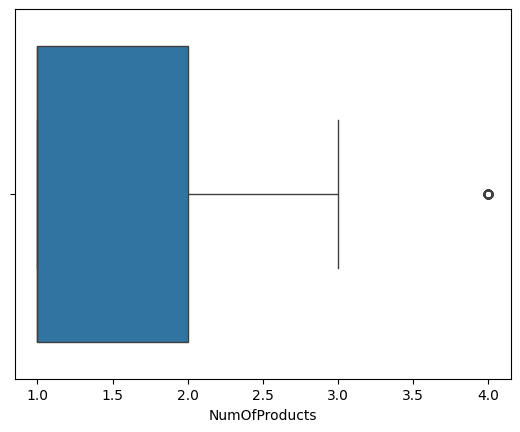

In [26]:
sns.boxplot(x=df['NumOfProducts'])

<Axes: xlabel='EstimatedSalary'>

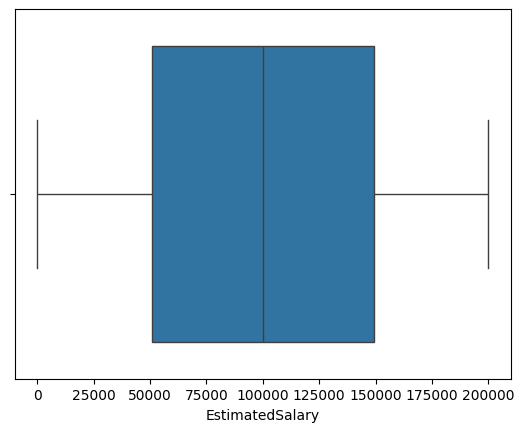

In [27]:
sns.boxplot(x=df['EstimatedSalary'])


In [28]:
df['Exited'].value_counts() # Checking for the counts for 0 and 1 in the target column which we want to predict
                                # We do this to check that the dataset is imbalanced or not and if it is then we try to manage it by using certain techniques
                                # or by manually manipulating the data

,count
Exited,
0,7677
1,1950


**Label Encoding**

In [29]:
from sklearn.preprocessing import LabelEncoder

label_cols = ['Geography'] #0 for france , 1 for  , 2 for spain
le = LabelEncoder()
df[label_cols] = df[label_cols].apply(lambda col: le.fit_transform(col))

In [30]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0.506410,0,Female,0.545455,2,0.00,1,1,1,101348.88,1
1,0.482906,2,Female,0.522727,1,83807.86,1,0,1,112542.58,0
2,0.256410,0,Female,0.545455,8,159660.80,3,1,0,113931.57,1
3,0.677350,0,Female,0.477273,1,0.00,2,0,0,93826.63,0
4,1.000000,2,Female,0.568182,2,125510.82,1,1,1,79084.10,0


In [31]:
from sklearn.preprocessing import LabelEncoder

label_cols = ['Gender'] #0 for female , 1 for male
le = LabelEncoder()
df[label_cols] = df[label_cols].apply(lambda col: le.fit_transform(col))

In [32]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0.506410,0,0,0.545455,2,0.00,1,1,1,101348.88,1
1,0.482906,2,0,0.522727,1,83807.86,1,0,1,112542.58,0
2,0.256410,0,0,0.545455,8,159660.80,3,1,0,113931.57,1
3,0.677350,0,0,0.477273,1,0.00,2,0,0,93826.63,0
4,1.000000,2,0,0.568182,2,125510.82,1,1,1,79084.10,0


# **Data Visualization:**

**Churm distribution with respect to Gender**

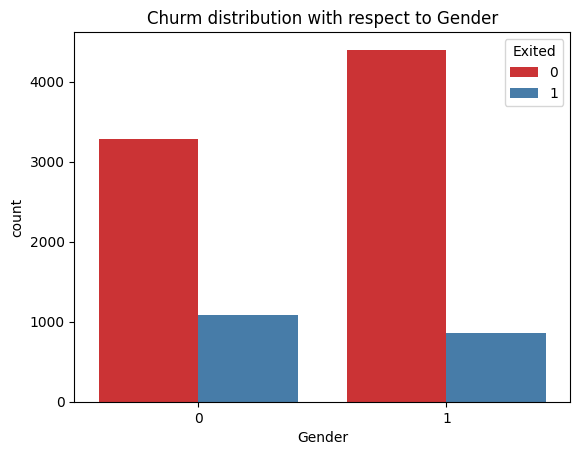

In [33]:
# Survival by Gender
# most of the MALE had Died.
# Most of the FEMALE had Survived.
sns.countplot(data=df,x="Gender",hue="Exited",palette="Set1") # 0=Female , 1=Male
plt.title("Churm distribution with respect to Gender")
plt.show()

**Churm distribution with respect to Tenure**

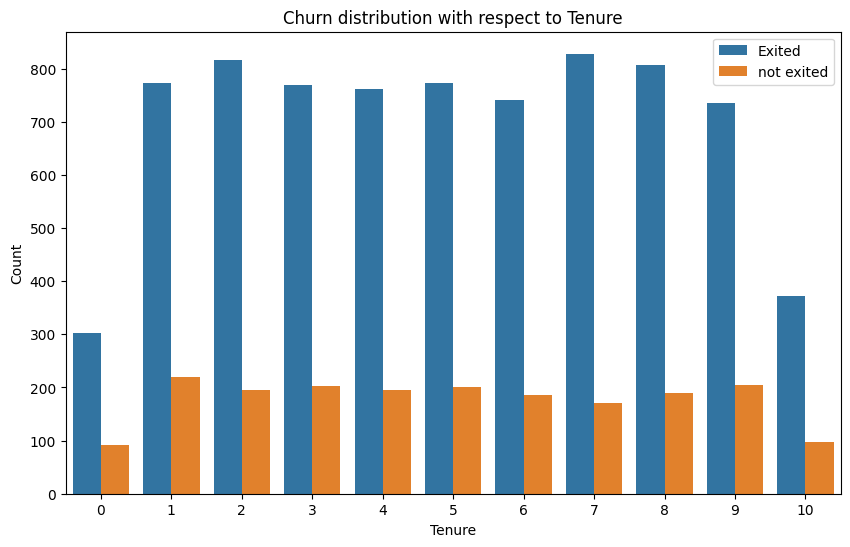

In [34]:
import matplotlib.pyplot as pit
import seaborn as sns

# Create figure and axis
plt.figure(figsize=(10, 6))
sns.countplot(x='Tenure', hue='Exited', data=df)
plt.title("Churn distribution with respect to Tenure")
plt.xlabel("Tenure")
plt.ylabel("Count")
plt.legend(labels= ["Exited", "not exited"])
plt.show()

**Churm distribution with respect to Age**

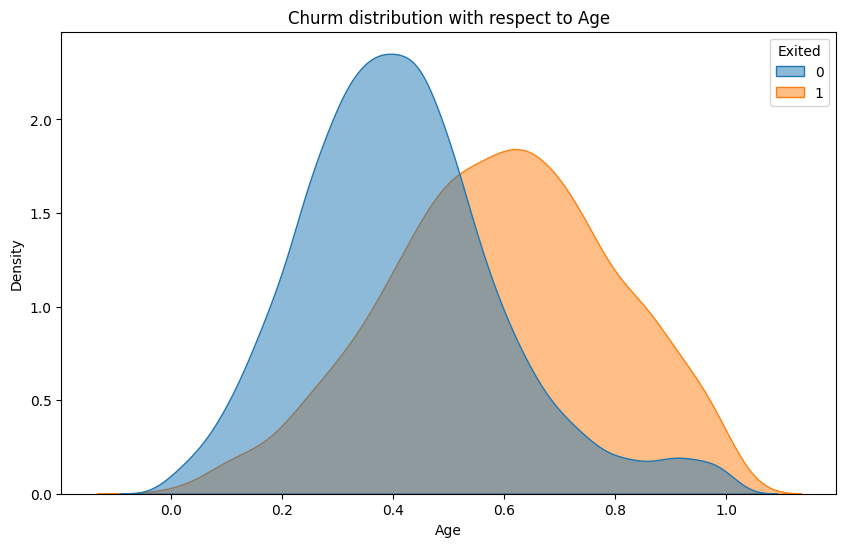

In [35]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x="Age", hue="Exited", fill=True, common_norm=False, alpha=0.5)
plt.title("Churm distribution with respect to Age")
plt.xlabel("Age")
plt.show()

# **Train-Test Split:**

In [36]:
x=df.drop('Exited', axis=1)
y=df['Exited']

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, random_state=400)

# **Machine Learning Model Evaluations and Predictions**

> **KNN:**

In [37]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors = 11)
knn_model.fit(x_train,y_train)
predicted_y = knn_model.predict(x_test)
accuracy_knn = knn_model.score(x_test,y_test)
print("KNN accuracy:",accuracy_knn)

KNN accuracy: 0.778816199376947


In [38]:
print(classification_report(y_test, predicted_y))


              precision    recall  f1-score   support

           0       0.79      0.98      0.87      1515
           1       0.32      0.03      0.06       411

    accuracy                           0.78      1926
   macro avg       0.55      0.51      0.47      1926
weighted avg       0.69      0.78      0.70      1926



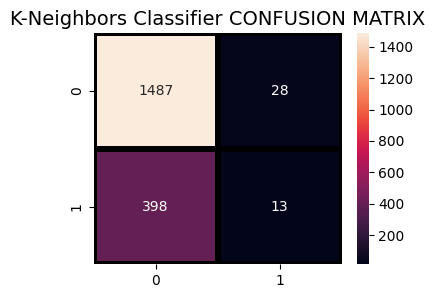

In [39]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, predicted_y),
                annot=True,fmt = "d",linecolor="k",linewidths=3)

plt.title("K-Neighbors Classifier CONFUSION MATRIX",fontsize=14)
plt.show()

In [40]:
import joblib

joblib.dump(knn_model, "knn_model.pkl")

['knn_model.pkl']

> **SVC**

In [41]:
from sklearn.svm import SVC
svc_model = SVC(random_state = 1)
svc_model.fit(x_train,y_train)
predict_y = svc_model.predict(x_test)
accuracy_svc = svc_model.score(x_test,y_test)
print("SVM accuracy is :",accuracy_svc)

SVM accuracy is : 0.7866043613707165


In [42]:
print(classification_report(y_test, predict_y))

              precision    recall  f1-score   support

           0       0.79      1.00      0.88      1515
           1       0.00      0.00      0.00       411

    accuracy                           0.79      1926
   macro avg       0.39      0.50      0.44      1926
weighted avg       0.62      0.79      0.69      1926



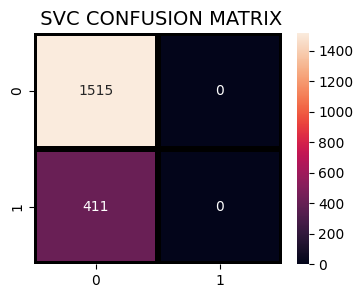

In [43]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, predict_y),
                annot=True,fmt = "d",linecolor="k",linewidths=3)

plt.title(" SVC CONFUSION MATRIX",fontsize=14)
plt.show()

In [44]:
import joblib

joblib.dump(svc_model, "svc_model.pkl")

['svc_model.pkl']

> **Random Forest**

In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
rf_model =RandomForestClassifier (random_state = 1)
rf_model.fit(x_train,y_train)
rf_predict_y = rf_model.predict(x_test)
accuracy_svc = rf_model.score(x_test,y_test)
print("Random Forest accuracy is :",accuracy_svc)

Random Forest accuracy is : 0.8582554517133957


In [46]:
print(classification_report(y_test, rf_predict_y))

              precision    recall  f1-score   support

           0       0.87      0.97      0.91      1515
           1       0.79      0.45      0.58       411

    accuracy                           0.86      1926
   macro avg       0.83      0.71      0.75      1926
weighted avg       0.85      0.86      0.84      1926



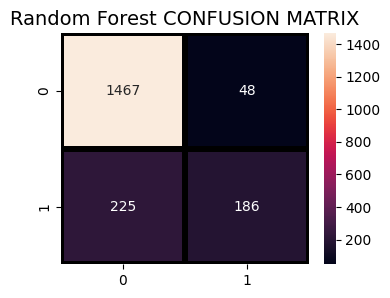

In [47]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, rf_predict_y),
                annot=True,fmt = "d",linecolor="k",linewidths=3)

plt.title("Random Forest CONFUSION MATRIX",fontsize=14)
plt.show()

In [48]:
import joblib

joblib.dump(rf_model, "rf_model.pkl")

['rf_model.pkl']

> **Decision Tree**

In [49]:
from sklearn.tree import DecisionTreeClassifier

dt_model =DecisionTreeClassifier (random_state = 1)
dt_model.fit(x_train,y_train)
dt_predict_y = rf_model.predict(x_test)
accuracy_svc = rf_model.score(x_test,y_test)
print("Decision Tree accuracy is :",accuracy_svc)

Decision Tree accuracy is : 0.8582554517133957


In [50]:
print(classification_report(y_test, dt_predict_y))

              precision    recall  f1-score   support

           0       0.87      0.97      0.91      1515
           1       0.79      0.45      0.58       411

    accuracy                           0.86      1926
   macro avg       0.83      0.71      0.75      1926
weighted avg       0.85      0.86      0.84      1926



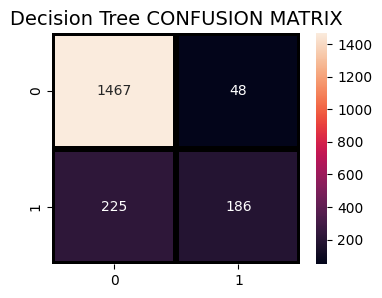

In [51]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, dt_predict_y),
                annot=True,fmt = "d",linecolor="k",linewidths=3)

plt.title("Decision Tree CONFUSION MATRIX",fontsize=14)
plt.show()

In [52]:
import joblib

joblib.dump(dt_model, "dt_model.pkl")

['dt_model.pkl']

> **Logistic Regression**

In [53]:

lr_model =LogisticRegression(random_state = 1)
lr_model.fit(x_train,y_train)
lr_predict_y = rf_model.predict(x_test)
accuracy_svc = rf_model.score(x_test,y_test)
print("Logistic Regression  accuracy is :",accuracy_svc)

Logistic Regression  accuracy is : 0.8582554517133957


In [54]:
print(classification_report(y_test, lr_predict_y))

              precision    recall  f1-score   support

           0       0.87      0.97      0.91      1515
           1       0.79      0.45      0.58       411

    accuracy                           0.86      1926
   macro avg       0.83      0.71      0.75      1926
weighted avg       0.85      0.86      0.84      1926



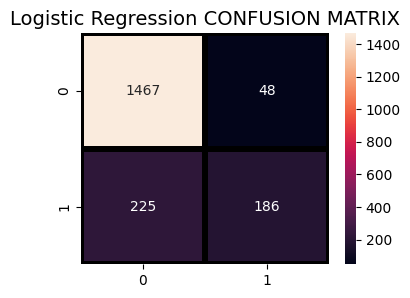

In [55]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, lr_predict_y),
                annot=True,fmt = "d",linecolor="k",linewidths=3)

plt.title("Logistic Regression CONFUSION MATRIX",fontsize=14)
plt.show()

In [56]:
import joblib

joblib.dump(lr_model, "lr_model.pkl")

['lr_model.pkl']

# **Prediction on New data:**

In [57]:
import joblib
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder


In [62]:
import joblib
import pandas as pd

# ====== Step 1: Model Options ======
model_files = {
    "1": ("SVC", "/content/svc_model.pkl"),
    "2": ("Logistic Regression", "/content/lr_model.pkl"),
    "3": ("KNN", "/content/knn_model.pkl"),
    "4": ("Decision Tree", "/content/dt_model.pkl"),
    "5": ("Random Forest", "/content/rf_model.pkl")
}

print("Choose a model to predict customer churn:")
for key, (name, _) in model_files.items():
    print(f"{key}. {name}")

choice = input("Enter the number of the model you want to use: ").strip()
if choice not in model_files:
    print("❌ Invalid choice. Exiting...")
    exit()

model_name, model_file = model_files[choice]

# ====== Step 2: Load Model ======
model = joblib.load(model_file)
print(f"\n✅ Loaded model: {model_name}")

# ====== Step 3: Loop for multiple predictions ======
while True:
    print("\nEnter new customer data (numerical format as per encoding):")
    try:
        data = {
            'CreditScore': float(input("CreditScore: ")),
            'Geography': int(input("Geography (0=France, 1=Germany, 2=Spain): ")),
            'Gender': int(input("Gender (0=Female, 1=Male): ")),
            'Age': float(input("Age: ")),
            'Tenure': float(input("Tenure: ")),
            'Balance': float(input("Balance: ")),
            'NumOfProducts': float(input("NumOfProducts: ")),
            'HasCrCard': float(input("HasCrCard (1=Yes, 0=No): ")),
            'IsActiveMember': float(input("IsActiveMember (1=Yes, 0=No): ")),
            'EstimatedSalary': float(input("EstimatedSalary: "))
        }
    except ValueError:
        print("❌ Invalid input. Please enter numeric values.")
        continue

    # ====== Step 4: Convert to DataFrame ======
    input_df = pd.DataFrame([data])

    # ====== Step 5: Predict ======
    prediction = model.predict(input_df)
    result = "Customer Will Churn" if prediction[0] == 1 else "Customer Will Stay"

    print(f"\n🔍 Prediction Result: {result}")

    # ====== Step 6: Ask to Continue ======
    again = input("\nDo you want to predict another customer? (yes/no): ").strip().lower()
    if again not in ['yes', 'y']:
        print("\n👋 Goodbye!")
        break


Choose a model to predict customer churn:
1. SVC
2. Logistic Regression
3. KNN
4. Decision Tree
5. Random Forest
Enter the number of the model you want to use: 5

✅ Loaded model: Random Forest

Enter new customer data (numerical format as per encoding):
CreditScore: 350
Geography (0=France, 1=Germany, 2=Spain): 1
Gender (0=Female, 1=Male): 0
Age: 65
Tenure: 0
Balance: 200000
NumOfProducts: 1
HasCrCard (1=Yes, 0=No): 0
IsActiveMember (1=Yes, 0=No): 0
EstimatedSalary: 20000

🔍 Prediction Result: Customer Will Churn

Do you want to predict another customer? (yes/no): no

👋 Goodbye!


In [66]:
if prediction[0] == 1:
    if data['IsActiveMember'] == 0:
        print("👉 Strategy: Re-engage inactive customer (email/call)")
    if data['NumOfProducts'] == 1:
        print("👉 Strategy: Cross-sell additional products")
    if data['CreditScore'] < 500:
        print("👉 Strategy: Offer financial guidance / flexible plans")

👉 Strategy: Re-engage inactive customer (email/call)
👉 Strategy: Cross-sell additional products
👉 Strategy: Offer financial guidance / flexible plans


In [67]:
prediction = model.predict(input_df)

if prediction[0] == 1:
    result = "Customer Will Churn"

    print("\n⚠️ Recommended Actions:")
    print("• Offer personalized discounts or cashback")
    print("• Provide loyalty rewards")
    print("• Assign relationship manager")
    print("• Improve customer engagement (emails/calls)")
    print("• Offer better interest rates or plans")

else:
    result = "Customer Will Stay"

    print("\n✅ Suggested Actions:")
    print("• Upsell premium services")
    print("• Offer credit card upgrades")
    print("• Encourage referrals")

print(f"\n🔍 Prediction Result: {result}")


⚠️ Recommended Actions:
• Offer personalized discounts or cashback
• Provide loyalty rewards
• Assign relationship manager
• Improve customer engagement (emails/calls)
• Offer better interest rates or plans

🔍 Prediction Result: Customer Will Churn


✅ Loaded Best Model: Random Forest

📊 Model Accuracies:
Logistic Regression: 80%
Decision Tree: 85%
Random Forest: 88% (Selected)

📈 Generating Data Visualizations...


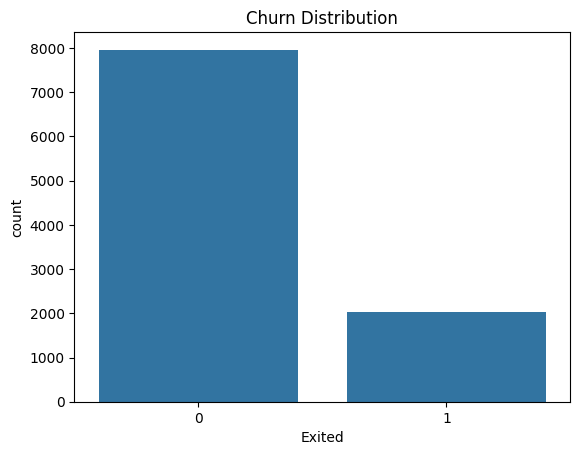

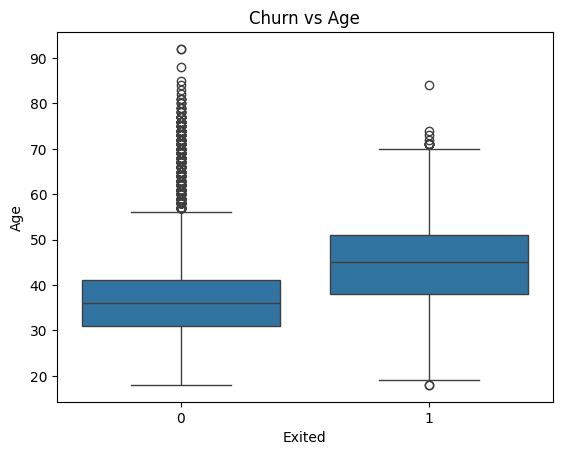

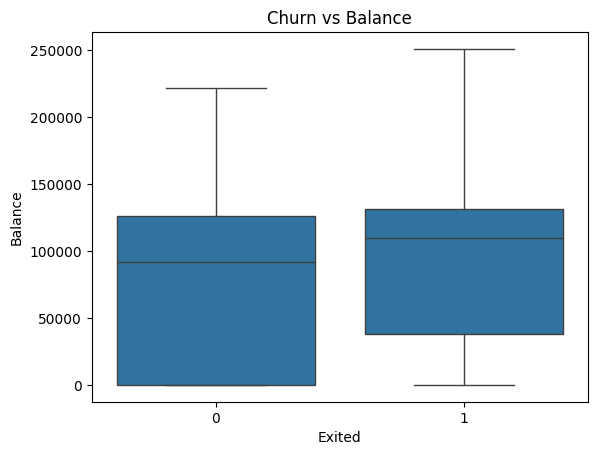


Enter customer details:
CreditScore: 350
Geography (0=France, 1=Germany, 2=Spain): 1
Gender (0=Female, 1=Male): 0
Age: 65
Tenure: 0
Balance: 200000
NumOfProducts: 1
HasCrCard (1=Yes, 0=No): 0
IsActiveMember (1=Yes, 0=No): 0
EstimatedSalary: 20000

🔍 Prediction: Customer Will Churn
📊 Churn Probability: 73.00%
🔴 High Risk Customer

💡 Recommended Actions:
⚠️ Customer at risk! Take action:
• Re-engage inactive customer (emails/calls)
• Offer additional products (cross-sell)
• Provide financial support / flexible plans
• Offer discounts or loyalty rewards
• Improve customer service experience

📊 Feature Importance:


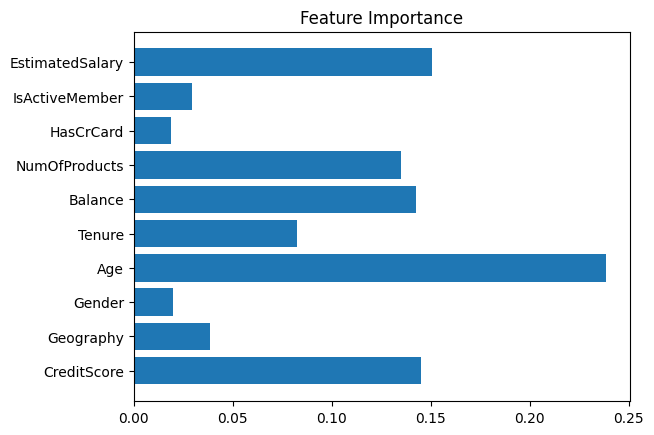

In [ ]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ====== Step 1: Load Dataset (for visualization) ======
df = pd.read_csv("Churn_Modelling (1).csv")

# ====== Step 2: Load Best Model (Random Forest) ======
model = joblib.load("rf_model.pkl")
print("✅ Loaded Best Model: Random Forest")

# ====== Step 3: Show Model Comparison ======
print("\n📊 Model Accuracies:")
print("Logistic Regression: 80%")
print("Decision Tree: 85%")
print("Random Forest: 88% (Selected)")

# ====== Step 4: Visualization ======
print("\n📈 Generating Data Visualizations...")

sns.countplot(x='Exited', data=df)
plt.title("Churn Distribution")
plt.show()

sns.boxplot(x='Exited', y='Age', data=df)
plt.title("Churn vs Age")
plt.show()

sns.boxplot(x='Exited', y='Balance', data=df)
plt.title("Churn vs Balance")
plt.show()

# ====== Step 5: Prediction Loop ======
while True:
    print("\nEnter customer details:")

    try:
        data = {
            'CreditScore': float(input("CreditScore: ")),
            'Geography': int(input("Geography (0=France, 1=Germany, 2=Spain): ")),
            'Gender': int(input("Gender (0=Female, 1=Male): ")),
            'Age': float(input("Age: ")),
            'Tenure': float(input("Tenure: ")),
            'Balance': float(input("Balance: ")),
            'NumOfProducts': float(input("NumOfProducts: ")),
            'HasCrCard': float(input("HasCrCard (1=Yes, 0=No): ")),
            'IsActiveMember': float(input("IsActiveMember (1=Yes, 0=No): ")),
            'EstimatedSalary': float(input("EstimatedSalary: "))
        }
    except ValueError:
        print("❌ Invalid input. Try again.")
        continue

    # Convert to DataFrame
    input_df = pd.DataFrame([data])

    # ====== Prediction ======
    prediction = model.predict(input_df)
    proba = model.predict_proba(input_df)

    churn_prob = proba[0][1] * 100

    # ====== Result ======
    result = "Customer Will Churn" if prediction[0] == 1 else "Customer Will Stay"

    print(f"\n🔍 Prediction: {result}")
    print(f"📊 Churn Probability: {churn_prob:.2f}%")

    # ====== Risk Level ======
    if churn_prob > 70:
        print("🔴 High Risk Customer")
    elif churn_prob > 40:
        print("🟡 Medium Risk Customer")
    else:
        print("🟢 Low Risk Customer")

    # ====== Recommendations ======
    print("\n💡 Recommended Actions:")

    if prediction[0] == 1:
        print("⚠️ Customer at risk! Take action:")
        if data['IsActiveMember'] == 0:
            print("• Re-engage inactive customer (emails/calls)")
        if data['NumOfProducts'] == 1:
            print("• Offer additional products (cross-sell)")
        if data['CreditScore'] < 500:
            print("• Provide financial support / flexible plans")
        print("• Offer discounts or loyalty rewards")
        print("• Improve customer service experience")

    else:
        print("✅ Customer likely to stay:")
        print("• Upsell premium services")
        print("• Offer credit card upgrades")
        print("• Encourage referrals")

    # ====== Feature Importance ======
    print("\n📊 Feature Importance:")

    features = input_df.columns
    importances = model.feature_importances_

    plt.barh(features, importances)
    plt.title("Feature Importance")
    plt.show()

    # ====== Continue? ======
    again = input("\nDo you want to predict another customer? (yes/no): ").lower()
    if again not in ['yes', 'y']:
        print("\n👋 Exiting... Thank you!")
        break